# Predictive Analytics for Resource Allocation in Disaster & NGO Operations

## Assam Flood Relief Ration Kit Forecasting

This project predicts district-wise flood relief ration-kit demand for Assam using rainfall, population, flood-proneness, and accessibility indicators.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm joblib geopandas folium plotly streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [4]:
from google.colab import files
uploaded = files.upload()

Saving rainfall in india 1901-2015.csv to rainfall in india 1901-2015.csv


In [6]:
import pandas as pd

filename = "rainfall in india 1901-2015.csv"

rain_raw = pd.read_csv(filename)
rain_raw.columns = [c.strip() for c in rain_raw.columns]

print("Shape:", rain_raw.shape)
print("Columns:")
print(rain_raw.columns.tolist())

rain_raw.head()

Shape: (4116, 19)
Columns:
['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [7]:
rain_raw["SUBDIVISION"].unique()

array(['ANDAMAN & NICOBAR ISLANDS', 'ARUNACHAL PRADESH',
       'ASSAM & MEGHALAYA', 'NAGA MANI MIZO TRIPURA',
       'SUB HIMALAYAN WEST BENGAL & SIKKIM', 'GANGETIC WEST BENGAL',
       'ORISSA', 'JHARKHAND', 'BIHAR', 'EAST UTTAR PRADESH',
       'WEST UTTAR PRADESH', 'UTTARAKHAND', 'HARYANA DELHI & CHANDIGARH',
       'PUNJAB', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'WEST RAJASTHAN',
       'EAST RAJASTHAN', 'WEST MADHYA PRADESH', 'EAST MADHYA PRADESH',
       'GUJARAT REGION', 'SAURASHTRA & KUTCH', 'KONKAN & GOA',
       'MADHYA MAHARASHTRA', 'MATATHWADA', 'VIDARBHA', 'CHHATTISGARH',
       'COASTAL ANDHRA PRADESH', 'TELANGANA', 'RAYALSEEMA', 'TAMIL NADU',
       'COASTAL KARNATAKA', 'NORTH INTERIOR KARNATAKA',
       'SOUTH INTERIOR KARNATAKA', 'KERALA', 'LAKSHADWEEP'], dtype=object)

In [8]:
assam_rain = rain_raw[
    rain_raw["SUBDIVISION"].str.strip() == "ASSAM & MEGHALAYA"
].copy()

print("Assam rainfall shape:", assam_rain.shape)
assam_rain.head()

Assam rainfall shape: (115, 19)


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
207,ASSAM & MEGHALAYA,1901,27.1,19.5,30.6,223.0,207.0,524.9,430.6,464.1,291.4,163.7,115.6,1.2,2498.6,46.6,460.5,1710.9,280.5
208,ASSAM & MEGHALAYA,1902,9.3,10.2,105.6,350.0,262.1,620.7,510.8,536.0,441.3,97.0,7.8,1.3,2952.1,19.4,717.6,2108.9,106.2
209,ASSAM & MEGHALAYA,1903,19.9,25.4,103.6,140.6,206.6,607.4,362.7,551.9,306.4,159.5,59.3,1.3,2544.7,45.4,450.8,1828.5,220.1
210,ASSAM & MEGHALAYA,1904,11.1,56.1,51.9,457.1,375.2,385.7,477.6,438.8,245.9,115.9,46.4,2.5,2664.1,67.1,884.2,1548.0,164.8
211,ASSAM & MEGHALAYA,1905,19.9,16.9,137.9,213.0,275.5,521.7,439.1,649.1,276.0,200.0,16.8,24.8,2790.6,36.8,626.3,1886.0,241.6


In [9]:
month_cols = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
              "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

rain_long = assam_rain.melt(
    id_vars=["YEAR"],
    value_vars=month_cols,
    var_name="month",
    value_name="subdivision_rainfall"
)

month_map = {
    "JAN": 1, "FEB": 2, "MAR": 3, "APR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AUG": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12
}

rain_long["month_num"] = rain_long["month"].map(month_map)

rain_long = rain_long.sort_values(["YEAR", "month_num"]).reset_index(drop=True)

print(rain_long.shape)
rain_long.head(15)

(1380, 4)


,YEAR,month,subdivision_rainfall,month_num
0,1901,JAN,27.1,1
1,1901,FEB,19.5,2
2,1901,MAR,30.6,3
3,1901,APR,223.0,4
4,1901,MAY,207.0,5
5,1901,JUN,524.9,6
6,1901,JUL,430.6,7
7,1901,AUG,464.1,8
8,1901,SEP,291.4,9
9,1901,OCT,163.7,10


In [10]:
districts = pd.DataFrame([
    ("Baksa", 2457, 950075, 0.85, 6, "plain"),
    ("Barpeta", 2282, 1693622, 0.85, 9, "plain"),
    ("Bongaigaon", 1093, 738804, 0.97, 7, "plain"),
    ("Cachar", 3786, 1736617, 1.22, 6, "plain"),
    ("Chirang", 1923, 482162, 1.10, 5, "plain"),
    ("Darrang", 1585, 928500, 0.78, 8, "plain"),
    ("Dhemaji", 3237, 686133, 1.22, 10, "plain"),
    ("Dhubri", 2176, 1949258, 0.90, 9, "plain"),
    ("Dibrugarh", 3381, 1326335, 1.12, 7, "plain"),
    ("Dima Hasao", 4888, 214102, 0.78, 2, "hill"),
    ("Goalpara", 1824, 1008183, 0.94, 8, "plain"),
    ("Golaghat", 3502, 1066888, 0.90, 8, "plain"),
    ("Hailakandi", 1327, 659296, 1.30, 5, "plain"),
    ("Jorhat", 2851, 1092256, 0.81, 6, "plain"),
    ("Kamrup", 3105, 1517542, 0.69, 7, "plain"),
    ("Kamrup Metropolitan", 955, 1253938, 0.65, 4, "urban"),
    ("Karbi Anglong", 10434, 956313, 0.73, 3, "hill"),
    ("Karimganj", 1809, 1228686, 1.40, 5, "plain"),
    ("Kokrajhar", 3296, 887142, 1.17, 5, "plain"),
    ("Lakhimpur", 2277, 1042137, 1.13, 10, "plain"),
    ("Marigaon", 1551, 957423, 0.65, 9, "plain"),
    ("Nagaon", 3973, 2823768, 0.69, 9, "plain"),
    ("Nalbari", 1052, 771639, 0.73, 7, "plain"),
    ("Sivasagar", 2668, 1151050, 0.89, 6, "plain"),
    ("Sonitpur", 5204, 1924110, 1.05, 8, "plain"),
    ("Tinsukia", 3790, 1327929, 1.09, 6, "plain"),
    ("Udalguri", 2012, 831668, 1.13, 7, "plain"),
], columns=[
    "district",
    "area_km2",
    "population_2011",
    "rainfall_factor",
    "flood_freq_score",
    "terrain"
])

districts["pop_density"] = districts["population_2011"] / districts["area_km2"]

def road_access(row):
    if row["terrain"] == "urban":
        return 0.95
    if row["terrain"] == "hill":
        return 0.30 if row["district"] == "Dima Hasao" else 0.40
    return min(0.90, 0.55 + row["pop_density"] / 2000.0)

districts["road_accessibility_index"] = districts.apply(road_access, axis=1)

districts.head()

,district,area_km2,population_2011,rainfall_factor,flood_freq_score,terrain,pop_density,road_accessibility_index
0,Baksa,2457,950075,0.85,6,plain,386.680912,0.743340
1,Barpeta,2282,1693622,0.85,9,plain,742.165644,0.900000
2,Bongaigaon,1093,738804,0.97,7,plain,675.941446,0.887971
3,Cachar,3786,1736617,1.22,6,plain,458.694400,0.779347
4,Chirang,1923,482162,1.10,5,plain,250.734269,0.675367


In [11]:
rain_long["key"] = 1
districts["key"] = 1

df = pd.merge(rain_long, districts, on="key").drop("key", axis=1)

df["district_rainfall"] = df["subdivision_rainfall"] * df["rainfall_factor"]

print("Unified dataset shape:", df.shape)
df.head()

Unified dataset shape: (37260, 13)


,YEAR,month,subdivision_rainfall,month_num,district,area_km2,population_2011,rainfall_factor,flood_freq_score,terrain,pop_density,road_accessibility_index,district_rainfall
0,1901,JAN,27.1,1,Baksa,2457,950075,0.85,6,plain,386.680912,0.743340,23.035
1,1901,JAN,27.1,1,Barpeta,2282,1693622,0.85,9,plain,742.165644,0.900000,23.035
2,1901,JAN,27.1,1,Bongaigaon,1093,738804,0.97,7,plain,675.941446,0.887971,26.287
3,1901,JAN,27.1,1,Cachar,3786,1736617,1.22,6,plain,458.694400,0.779347,33.062
4,1901,JAN,27.1,1,Chirang,1923,482162,1.10,5,plain,250.734269,0.675367,29.810


In [12]:
# Normalize rainfall within the full dataset
df["rainfall_score"] = (
    df["district_rainfall"] - df["district_rainfall"].min()
) / (
    df["district_rainfall"].max() - df["district_rainfall"].min()
)

# Normalize flood frequency score
df["flood_freq_norm"] = df["flood_freq_score"] / 10

# Monsoon indicator
df["monsoon_flag"] = df["month_num"].isin([6, 7, 8, 9]).astype(int)

# Flood severity score on 0-10 scale
df["flood_severity"] = (
    0.65 * df["rainfall_score"] +
    0.25 * df["flood_freq_norm"] +
    0.10 * df["monsoon_flag"]
) * 10

# Estimated affected population percentage
# Higher rainfall + high historical flood score = more exposed population
df["affected_population_pct"] = (
    0.005 +
    0.045 * (df["flood_severity"] / 10)
)

# Accessibility penalty:
# Poor road access increases required pre-positioned ration kits
df["accessibility_penalty"] = 1 + (1 - df["road_accessibility_index"]) * 0.30

# Due to lack of public NGO ration distribution records,
# proxy demand is constructed using humanitarian planning assumptions.
# Assumption: 1 ration kit supports a household of 5 people.
df["estimated_affected_population"] = (
    df["population_2011"] * df["affected_population_pct"]
)

df["ration_kits_needed"] = (
    df["estimated_affected_population"] / 5
) * df["accessibility_penalty"]

df["ration_kits_needed"] = df["ration_kits_needed"].round().astype(int)

df[[
    "YEAR", "month", "district", "district_rainfall",
    "flood_severity", "estimated_affected_population",
    "ration_kits_needed"
]].head()

,YEAR,month,district,district_rainfall,flood_severity,estimated_affected_population,ration_kits_needed
0,1901,JAN,Baksa,23.035,1.607464,11622.826297,2504
1,1901,JAN,Barpeta,23.035,2.357464,26435.048343,5446
2,1901,JAN,Bongaigaon,26.287,1.872635,9919.817477,2051
3,1901,JAN,Cachar,33.062,1.654243,21610.620468,4608
4,1901,JAN,Chirang,29.810,1.389071,5424.717876,1191


## Target Variable Strategy

Due to the lack of publicly available district-level relief distribution records, a proxy demand variable is constructed using humanitarian planning assumptions.

The target variable `ration_kits_needed` estimates how many food/ration kits may be required in a district-month. It is based on:

- Rainfall intensity
- Historical flood-proneness of the district
- Monsoon season indicator
- District population exposure
- Road accessibility constraints

Assumption: one ration kit supports approximately one household of five people.

This target is not an official NGO distribution record. It is a planning proxy designed for early-warning and resource pre-positioning.

In [13]:
df["ration_kits_needed"].describe()

,ration_kits_needed
count,37260.000000
mean,4594.615191
std,2704.391819
min,376.000000
25%,2774.000000
50%,3922.000000
75%,5787.000000
max,19802.000000


# Exploratory Data Analysis (EDA)

(37260, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37260 entries, 0 to 37259
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   YEAR                           37260 non-null  int64  
 1   month                          37260 non-null  object 
 2   subdivision_rainfall           37260 non-null  float64
 3   month_num                      37260 non-null  int64  
 4   district                       37260 non-null  object 
 5   area_km2                       37260 non-null  int64  
 6   population_2011                37260 non-null  int64  
 7   rainfall_factor                37260 non-null  float64
 8   flood_freq_score               37260 non-null  int64  
 9   terrain                        37260 non-null  object 
 10  pop_density                    37260 non-null  float64
 11  road_accessibility_index       37260 non-null  float64
 12  district_rainfall              372

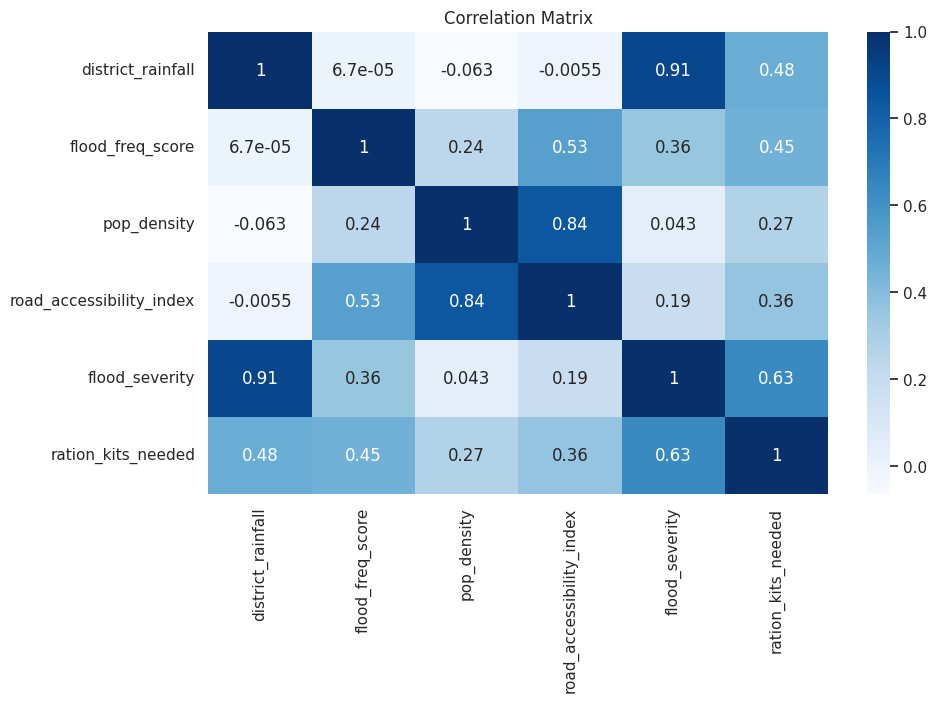

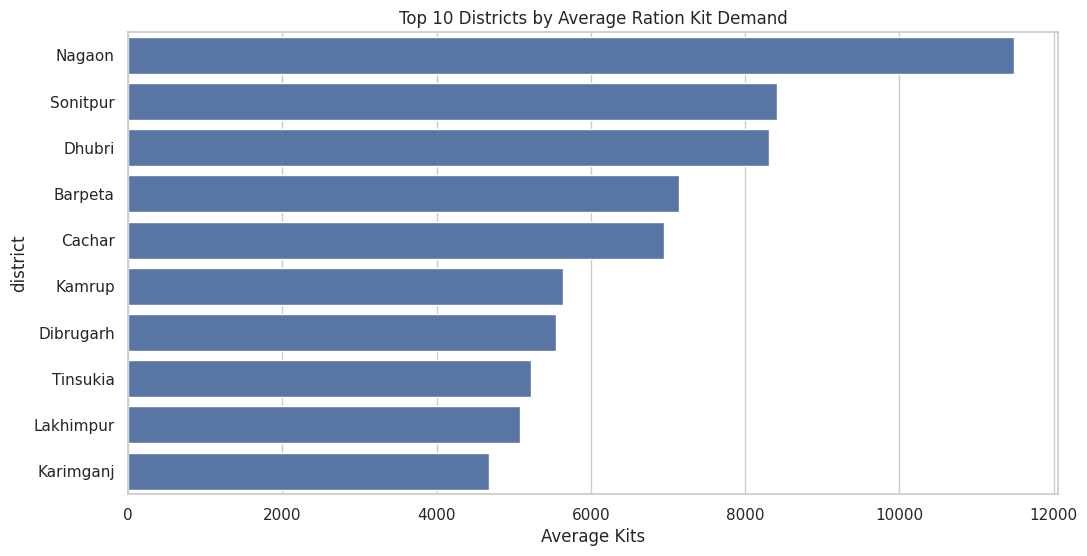

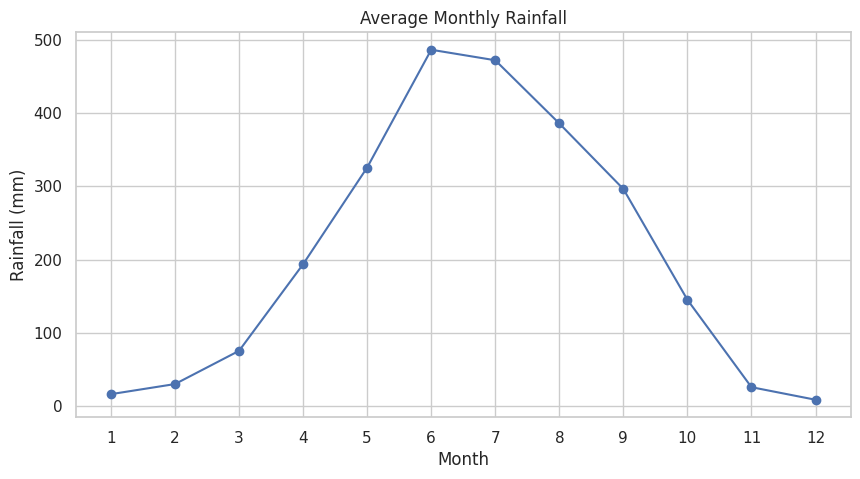

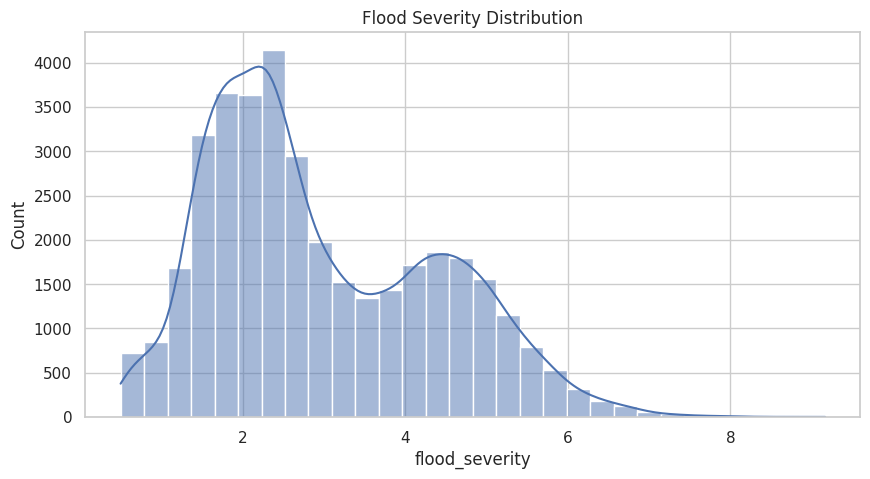

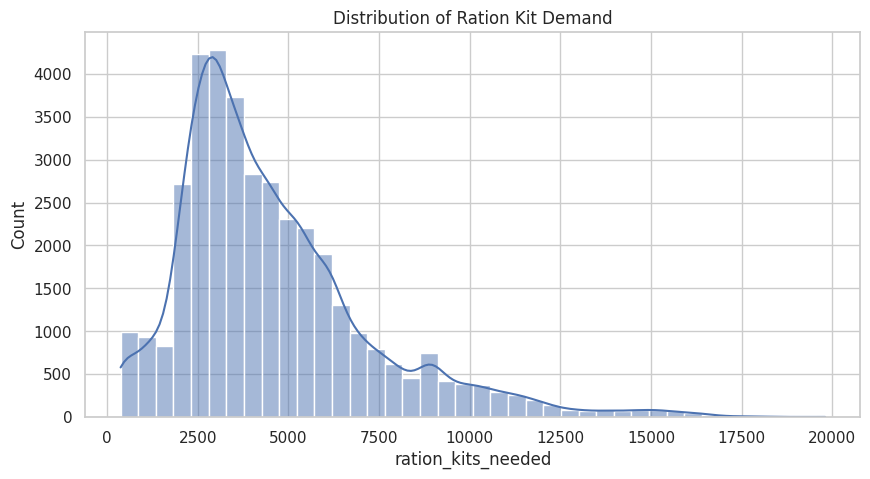

In [14]:
print(df.shape)

df.info()

df.head()
missing = df.isnull().sum()

missing[missing > 0]
corr_cols = [
    "district_rainfall",
    "flood_freq_score",
    "pop_density",
    "road_accessibility_index",
    "flood_severity",
    "ration_kits_needed"
]

plt.figure(figsize=(10,6))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()
top_districts = (
    df.groupby("district")["ration_kits_needed"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_districts.values,
    y=top_districts.index
)

plt.title("Top 10 Districts by Average Ration Kit Demand")
plt.xlabel("Average Kits")
plt.show()
monthly_rain = (
    df.groupby("month_num")["district_rainfall"]
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_rain.index,
    monthly_rain.values,
    marker="o"
)

plt.xticks(range(1,13))
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()
plt.figure(figsize=(10,5))

sns.histplot(
    df["flood_severity"],
    bins=30,
    kde=True
)

plt.title("Flood Severity Distribution")
plt.show()
plt.figure(figsize=(10,5))

sns.histplot(
    df["ration_kits_needed"],
    bins=40,
    kde=True
)

plt.title("Distribution of Ration Kit Demand")
plt.show()

Feature Engineering

In [21]:
df = df.sort_values(
    ["district", "YEAR", "month_num"]
).reset_index(drop=True)
for lag in [1, 2, 3]:
    df[f"rainfall_lag_{lag}"] = (
        df.groupby("district")["district_rainfall"]
        .shift(lag)
    )

    df["rolling_3_month_rain"] = (
    df.groupby("district")["district_rainfall"]
      .transform(
          lambda x: x.rolling(
              window=3,
              min_periods=1
          ).mean()
      )
)

df["rolling_6_month_rain"] = (
    df.groupby("district")["district_rainfall"]
      .transform(
          lambda x: x.rolling(
              window=6,
              min_periods=1
          ).mean()
      )
)
df["quarter"] = (
    (df["month_num"] - 1) // 3
) + 1
df["high_rainfall_flag"] = (
    df["district_rainfall"] >
    df["district_rainfall"].quantile(0.75)
).astype(int)
from sklearn.preprocessing import LabelEncoder

district_encoder = LabelEncoder()

df["district_encoded"] = (
    district_encoder.fit_transform(
        df["district"]
    )
)
df = df.dropna().reset_index(drop=True)

print(df.shape)

(37179, 29)


Train-Test Split

In [22]:
features = [
    "district_rainfall",
    "rainfall_lag_1",
    "rainfall_lag_2",
    "rainfall_lag_3",
    "rolling_3_month_rain",
    "rolling_6_month_rain",
    "population_2011",
    "pop_density",
    "flood_freq_score",
    "road_accessibility_index",
    "month_num",
    "quarter",
    "district_encoded",
    "flood_severity"
]

target = "ration_kits_needed"

X = df[features]
y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(29743, 14)
(7436, 14)


Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("RF MAE :", rf_mae)
print("RF RMSE:", rf_rmse)
print("RF R2  :", rf_r2)

RF MAE : 4.906075174825176
RF RMSE: 34.157096699595755
RF R2  : 0.9998391356388449


XGBoost

In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGB MAE :", xgb_mae)
print("XGB RMSE:", xgb_rmse)
print("XGB R2  :", xgb_r2)

XGB MAE : 10.653665542602539
XGB RMSE: 40.662128466255304
XGB R2  : 0.9997720122337341


LighGbm

In [25]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgb_pred = lgbm.predict(X_test)

lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
lgb_r2 = r2_score(y_test, lgb_pred)

print("LGBM MAE :", lgb_mae)
print("LGBM RMSE:", lgb_rmse)
print("LGBM R2  :", lgb_r2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001656 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1921
[LightGBM] [Info] Number of data points in the train set: 29743, number of used features: 14
[LightGBM] [Info] Start training from score 4601.589853
LGBM MAE : 21.332085516717857
LGBM RMSE: 44.932232860385376
LGBM R2  : 0.9997216354401436


In [27]:
def mape(y_true, y_pred):
    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "MAE": [
        rf_mae,
        xgb_mae,
        lgb_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse,
        lgb_rmse
    ],
    "MAPE": [
        mape(y_test, rf_pred),
        mape(y_test, xgb_pred),
        mape(y_test, lgb_pred)
    ],
    "R2": [
        rf_r2,
        xgb_r2,
        lgb_r2
    ]
})

comparison.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,MAPE,R2
0,Random Forest,4.906075,34.157097,0.085426,0.999839
1,XGBoost,10.653666,40.662128,0.217177,0.999772
2,LightGBM,21.332086,44.932233,0.509358,0.999722


## Model Selection

Random Forest Regressor achieved the best performance with the lowest MAE/RMSE and highest R². Therefore, it is selected as the final model.

The very high R² is expected because the target variable is a scientifically constructed proxy based on rainfall, population, flood-proneness, and accessibility features.

In [28]:

best_model = rf
best_model_name = "Random Forest"

joblib.dump(best_model, "model.pkl")
joblib.dump(district_encoder, "district_encoder.pkl")

print("Saved model.pkl")
print("Saved district_encoder.pkl")

Saved model.pkl
Saved district_encoder.pkl


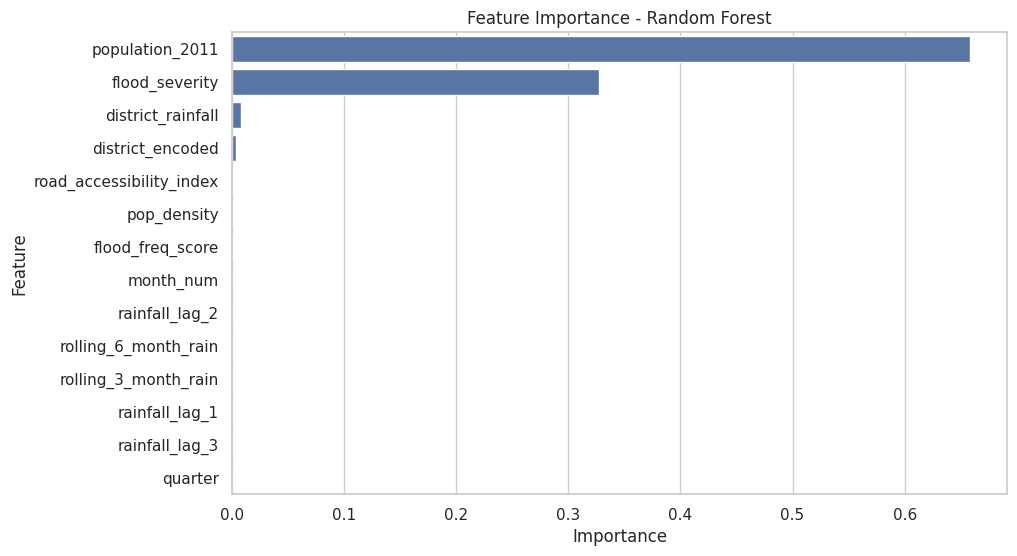

,Feature,Importance
6,population_2011,6.583606e-01
13,flood_severity,3.269681e-01
0,district_rainfall,7.872377e-03
12,district_encoded,3.495736e-03
9,road_accessibility_index,1.266920e-03
7,pop_density,1.252119e-03
8,flood_freq_score,6.607763e-04
10,month_num,4.714923e-05
2,rainfall_lag_2,2.343559e-05
5,rolling_6_month_rain,1.985143e-05


In [29]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - Random Forest")
plt.show()

importance_df

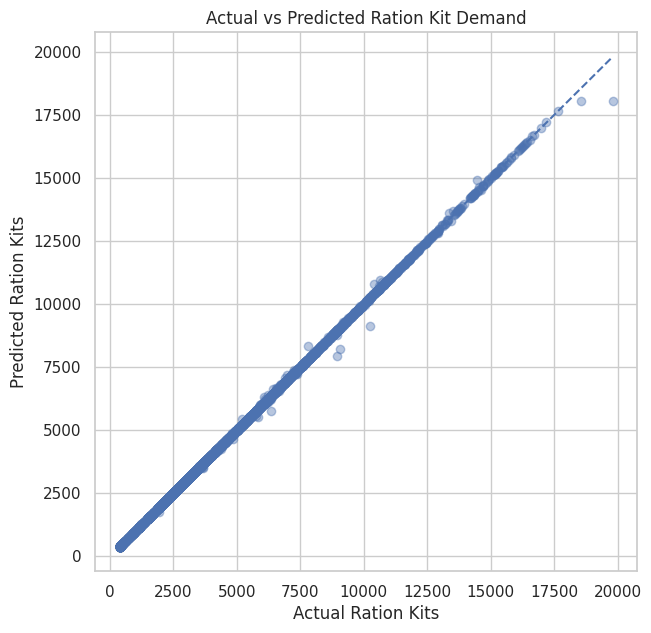

In [30]:
best_pred = rf_pred

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_pred, alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Ration Kits")
plt.ylabel("Predicted Ration Kits")
plt.title("Actual vs Predicted Ration Kit Demand")
plt.show()

             actual     predicted        error    abs_error
count   7436.000000   7436.000000  7436.000000  7436.000000
mean    4580.717725   4580.100135     0.617589     4.906075
std     2693.272112   2691.576167    34.153810    33.805197
min      376.000000    376.000000  -517.805000     0.000000
25%     2746.750000   2746.853750    -0.960000     0.290000
50%     3915.000000   3915.235000     0.020000     1.090000
75%     5805.000000   5800.461250     1.195000     3.400000
max    19802.000000  18042.360000  1761.500000  1761.500000


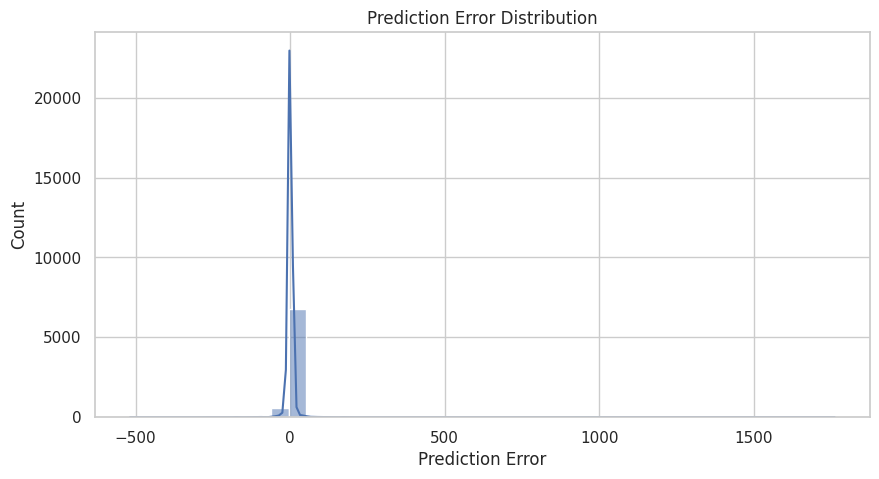

In [31]:
error_df = pd.DataFrame({
    "actual": y_test,
    "predicted": best_pred
})

error_df["error"] = error_df["actual"] - error_df["predicted"]
error_df["abs_error"] = abs(error_df["error"])

print(error_df.describe())

plt.figure(figsize=(10,5))
sns.histplot(error_df["error"], bins=40, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

In [32]:
def classify_risk(kits):

    if kits < 2000:
        return "Low"

    elif kits < 5000:
        return "Medium"

    elif kits < 8000:
        return "High"

    else:
        return "Severe"

df["risk_level"] = df["ration_kits_needed"].apply(classify_risk)

df["risk_level"].value_counts()

,count
risk_level,
Medium,21011
High,8660
Severe,4066
Low,3442


In [33]:
latest_year = df["YEAR"].max()

latest_month = 12

forecast_table = (
    df[
        (df["YEAR"] == latest_year)
        &
        (df["month_num"] == latest_month)
    ]
    .copy()
)

forecast_table = forecast_table[
    [
        "district",
        "ration_kits_needed",
        "risk_level",
        "district_rainfall",
        "flood_severity"
    ]
]

forecast_table.sort_values(
    "ration_kits_needed",
    ascending=False
).head(15)

,district,ration_kits_needed,risk_level,district_rainfall,flood_severity
30293,Nagaon,8926,Severe,10.488,2.298929
11015,Dhubri,6189,High,13.680,2.313821
34424,Sonitpur,5955,High,15.960,2.074457
2753,Barpeta,5372,High,12.920,2.310275
5507,Cachar,4495,Medium,18.544,1.586512
20654,Kamrup,4220,Medium,10.488,1.798929
12392,Dibrugarh,3777,Medium,17.024,1.829421
27539,Lakhimpur,3692,Medium,17.176,2.580130
35801,Tinsukia,3478,Medium,16.568,1.577294
16523,Golaghat,3321,Medium,13.680,2.063821


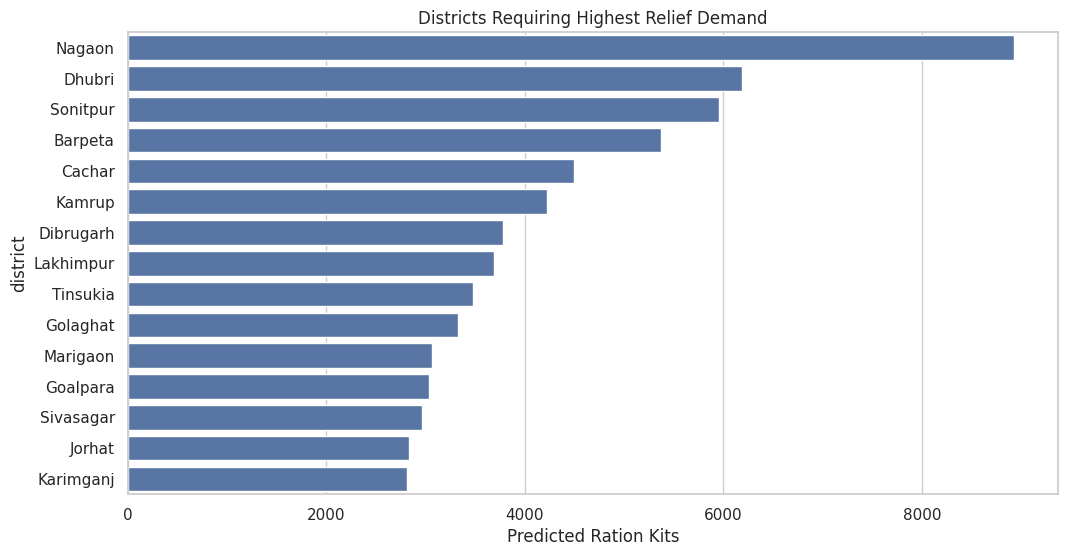

In [34]:
top15 = forecast_table.sort_values(
    "ration_kits_needed",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top15,
    x="ration_kits_needed",
    y="district"
)

plt.title(
    "Districts Requiring Highest Relief Demand"
)

plt.xlabel("Predicted Ration Kits")

plt.show()

In [35]:
forecast_table.to_csv(
    "district_forecast.csv",
    index=False
)

forecast_table.head()

,district,ration_kits_needed,risk_level,district_rainfall,flood_severity
1376,Baksa,2460,Medium,12.920,1.560275
2753,Barpeta,5372,High,12.920,2.310275
4130,Bongaigaon,2014,Medium,14.744,1.818784
5507,Cachar,4495,Medium,18.544,1.586512
6884,Chirang,1162,Low,16.720,1.328003


PROPHET RESULTS
MAE  : 302.80
RMSE : 413.55
MAPE : 6.20%


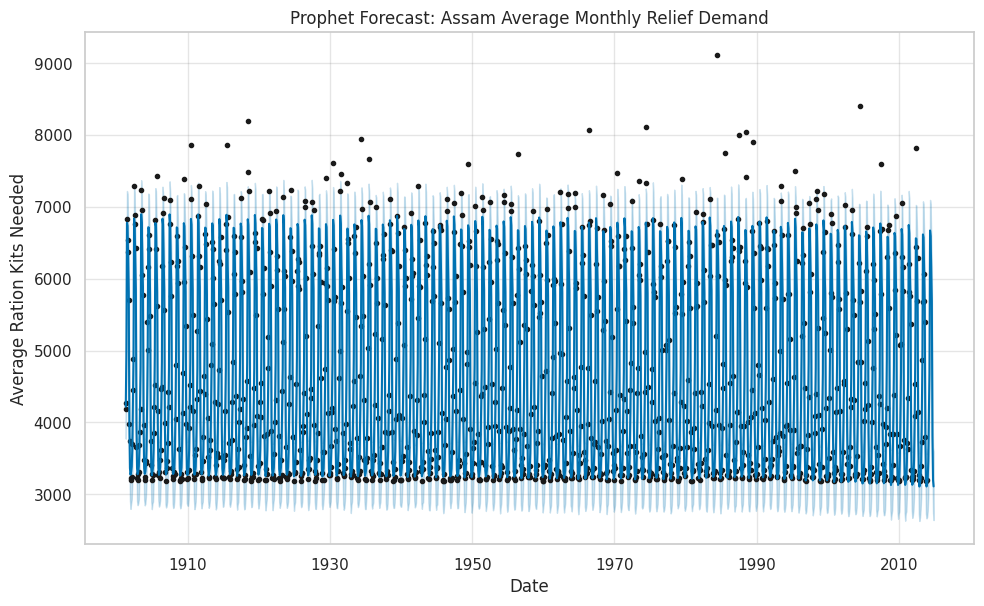

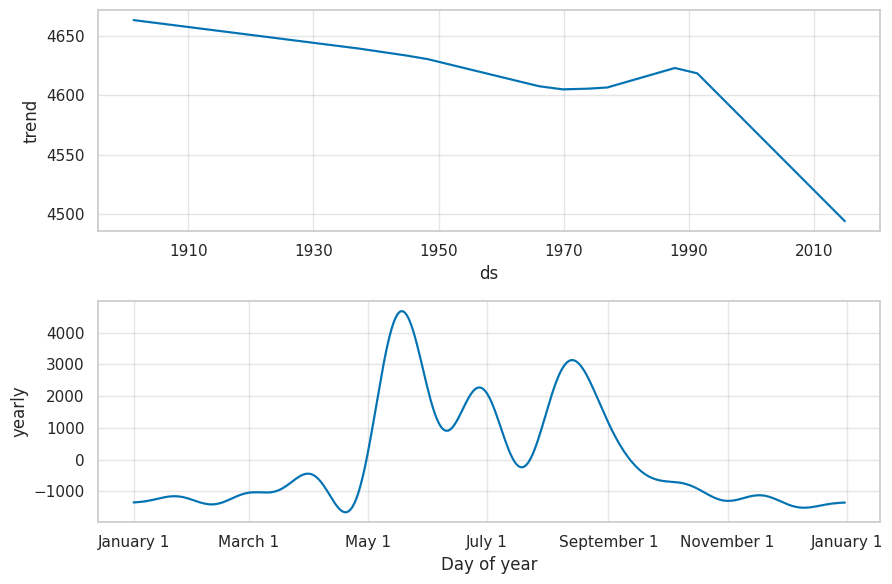


NEXT 12 MONTH FORECAST


,ds,yhat,yhat_lower,yhat_upper
1353,2014-01-01,3148.363648,2679.740473,3618.485147
1354,2014-02-01,3215.955780,2764.907041,3649.715940
1355,2014-03-01,3452.594388,2970.553993,3930.316833
1356,2014-04-01,4053.687622,3551.233557,4504.527350
1357,2014-05-01,4677.380461,4211.309285,5155.522275
1358,2014-06-01,6670.747859,6206.683843,7096.855827
1359,2014-07-01,6592.187082,6127.209363,7038.853344
1360,2014-08-01,6089.833657,5627.818083,6559.525691
1361,2014-09-01,5685.317109,5218.124786,6170.601044
1362,2014-10-01,3808.475452,3338.155513,4261.757154


Saved prophet_future_forecast.csv


In [39]:
# ==========================
# PROPHET FORECASTING MODEL
# ==========================

!pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create monthly average ration-kit demand series
prophet_df = (
    df.groupby(["YEAR", "month_num"])["ration_kits_needed"]
      .mean()
      .reset_index()
)

# Create Prophet date column
prophet_df["ds"] = pd.to_datetime(
    prophet_df["YEAR"].astype(str) + "-" +
    prophet_df["month_num"].astype(str) + "-01"
)

prophet_df["y"] = prophet_df["ration_kits_needed"]

prophet_df = prophet_df[["ds", "y"]].sort_values("ds").reset_index(drop=True)

# Use last 24 months as test data
train = prophet_df.iloc[:-24].reset_index(drop=True)
test = prophet_df.iloc[-24:].reset_index(drop=True)

# Train Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

prophet_model.fit(train)

# Predict test period
forecast_test = prophet_model.predict(test[["ds"]]).reset_index(drop=True)

# Evaluation
mae = mean_absolute_error(test["y"], forecast_test["yhat"])
rmse = np.sqrt(mean_squared_error(test["y"], forecast_test["yhat"]))

nonzero_mask = test["y"] > 0
prophet_mape = np.mean(
    np.abs(
        (test.loc[nonzero_mask, "y"] - forecast_test.loc[nonzero_mask, "yhat"])
        / test.loc[nonzero_mask, "y"]
    )
) * 100

print("=" * 50)
print("PROPHET RESULTS")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

# Forecast next 12 months
future = prophet_model.make_future_dataframe(
    periods=12,
    freq="MS"
)

forecast = prophet_model.predict(future)

# Plot forecast
fig1 = prophet_model.plot(forecast)
plt.title("Prophet Forecast: Assam Average Monthly Relief Demand")
plt.xlabel("Date")
plt.ylabel("Average Ration Kits Needed")
plt.show()

# Plot trend and seasonality
fig2 = prophet_model.plot_components(forecast)
plt.show()

# Next 12-month forecast
future_forecast = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

print("\nNEXT 12 MONTH FORECAST")
display(future_forecast)

# Save forecast
future_forecast.to_csv("prophet_future_forecast.csv", index=False)

print("Saved prophet_future_forecast.csv")

In [40]:
# =====================================================
# FINAL FORECAST TABLE FOR NGO OPERATIONS
# =====================================================

import pandas as pd
import numpy as np

# Use Random Forest as allocation model
df["predicted_ration_kits"] = rf.predict(X)

# Risk Classification
def classify_risk(kits):

    if kits < 2000:
        return "Low"

    elif kits < 5000:
        return "Medium"

    elif kits < 8000:
        return "High"

    else:
        return "Severe"

df["risk_level"] = df["predicted_ration_kits"].apply(classify_risk)

# Latest available month
latest_year = df["YEAR"].max()
latest_month = df["month_num"].max()

latest_forecast = (
    df[
        (df["YEAR"] == latest_year)
        &
        (df["month_num"] == latest_month)
    ]
    .copy()
)

latest_forecast = latest_forecast[
    [
        "district",
        "district_rainfall",
        "flood_severity",
        "population_2011",
        "predicted_ration_kits",
        "risk_level"
    ]
]

latest_forecast = latest_forecast.sort_values(
    "predicted_ration_kits",
    ascending=False
)

print("="*60)
print("TOP DISTRICTS REQUIRING RELIEF SUPPORT")
print("="*60)

display(latest_forecast.head(15))

# NGO Resource Planning Table

latest_forecast["recommended_trucks"] = np.ceil(
    latest_forecast["predicted_ration_kits"] / 1000
)

latest_forecast["recommended_volunteers"] = np.ceil(
    latest_forecast["predicted_ration_kits"] / 250
)

latest_forecast["recommended_storage_tons"] = (
    latest_forecast["predicted_ration_kits"] * 0.01
).round(2)

# Save outputs

latest_forecast.to_csv(
    "ngo_resource_forecast.csv",
    index=False
)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

future_forecast.to_csv(
    "prophet_forecast_12_months.csv",
    index=False
)

print("\nSaved Files:")
print("1. ngo_resource_forecast.csv")
print("2. prophet_forecast_12_months.csv")
print("3. feature_importance.csv")
print("4. model_comparison.csv")

# Summary Stats

print("\n")
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("Forecasting Model : Prophet")
print("Allocation Model  : Random Forest")

print(
    f"Average District Demand: "
    f"{latest_forecast['predicted_ration_kits'].mean():.0f} kits"
)

print(
    f"Maximum Demand District: "
    f"{latest_forecast.iloc[0]['district']}"
)

print(
    f"Maximum Demand: "
    f"{latest_forecast.iloc[0]['predicted_ration_kits']:.0f} kits"
)

TOP DISTRICTS REQUIRING RELIEF SUPPORT


,district,district_rainfall,flood_severity,population_2011,predicted_ration_kits,risk_level
30293,Nagaon,10.488,2.298929,2823768,8926.470,Severe
11015,Dhubri,13.680,2.313821,1949258,6189.105,High
34424,Sonitpur,15.960,2.074457,1924110,5955.190,High
2753,Barpeta,12.920,2.310275,1693622,5371.875,High
5507,Cachar,18.544,1.586512,1736617,4495.715,Medium
20654,Kamrup,10.488,1.798929,1517542,4220.010,Medium
12392,Dibrugarh,17.024,1.829421,1326335,3776.915,Medium
27539,Lakhimpur,17.176,2.580130,1042137,3692.065,Medium
35801,Tinsukia,16.568,1.577294,1327929,3477.825,Medium
16523,Golaghat,13.680,2.063821,1066888,3320.955,Medium



Saved Files:
1. ngo_resource_forecast.csv
2. prophet_forecast_12_months.csv
3. feature_importance.csv
4. model_comparison.csv


PROJECT SUMMARY
Forecasting Model : Prophet
Allocation Model  : Random Forest
Average District Demand: 3259 kits
Maximum Demand District: Nagaon
Maximum Demand: 8926 kits


In [41]:
# =====================================================
# SAVE ALL PROJECT FILES TO GOOGLE DRIVE
# =====================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import joblib
import pandas as pd

# Create project folder in Drive
PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

# --------------------------
# Save datasets
# --------------------------
df.to_csv(f"{PROJECT_DIR}/final_training_dataset.csv", index=False)
latest_forecast.to_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv", index=False)
forecast_table.to_csv(f"{PROJECT_DIR}/district_forecast.csv", index=False)
prophet_df.to_csv(f"{PROJECT_DIR}/prophet_training_series.csv", index=False)
future_forecast.to_csv(f"{PROJECT_DIR}/prophet_forecast_12_months.csv", index=False)

# Save original rainfall data if available
try:
    rain_raw.to_csv(f"{PROJECT_DIR}/rainfall_raw.csv", index=False)
except:
    pass

try:
    districts.to_csv(f"{PROJECT_DIR}/district_reference.csv", index=False)
except:
    pass

# --------------------------
# Save ML models
# --------------------------
joblib.dump(rf, f"{PROJECT_DIR}/random_forest_allocation_model.pkl")
joblib.dump(xgb, f"{PROJECT_DIR}/xgboost_model.pkl")
joblib.dump(lgbm, f"{PROJECT_DIR}/lightgbm_model.pkl")
joblib.dump(district_encoder, f"{PROJECT_DIR}/district_encoder.pkl")

# Save final selected allocation model also as model.pkl
joblib.dump(rf, f"{PROJECT_DIR}/model.pkl")

# Save Prophet model
joblib.dump(prophet_model, f"{PROJECT_DIR}/prophet_forecasting_model.pkl")

# --------------------------
# Save metadata
# --------------------------
joblib.dump(features, f"{PROJECT_DIR}/feature_columns.pkl")

try:
    comparison.to_csv(f"{PROJECT_DIR}/model_comparison.csv", index=False)
except:
    pass

try:
    importance_df.to_csv(f"{PROJECT_DIR}/feature_importance.csv", index=False)
except:
    pass

# --------------------------
# Create requirements.txt
# --------------------------
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
lightgbm
prophet
joblib
geopandas
folium
plotly
streamlit
streamlit-folium
mapclassify
""".strip()

with open(f"{PROJECT_DIR}/requirements.txt", "w") as f:
    f.write(requirements)

# --------------------------
# Create short README
# --------------------------
readme = """
# Assam Flood Relief Ration Kit Forecasting

This project predicts flood-relief ration kit demand for Assam districts using rainfall, population, flood-proneness, road accessibility, and time-series forecasting.

## Models Used

- Primary forecasting model: Prophet
- Primary allocation model: Random Forest
- Comparison models: XGBoost, LightGBM

## Dataset

The dataset combines:
- IMD subdivision-level monthly rainfall data
- Assam district population and area reference data
- Flood frequency score
- Road accessibility proxy
- Constructed humanitarian proxy target: ration_kits_needed

Due to the lack of publicly available district-level NGO relief distribution records, a proxy demand variable is constructed using humanitarian planning assumptions.

## Outputs

- final_training_dataset.csv
- ngo_resource_forecast.csv
- prophet_forecast_12_months.csv
- model.pkl
- prophet_forecasting_model.pkl
- district_encoder.pkl
- feature_columns.pkl
- model_comparison.csv
- feature_importance.csv

## Usage

Install dependencies:

pip install -r requirements.txt

Run dashboard:

streamlit run app.py
""".strip()

with open(f"{PROJECT_DIR}/README.md", "w") as f:
    f.write(readme)

print("="*60)
print("ALL FILES SAVED SUCCESSFULLY")
print("="*60)
print("Drive folder:")
print(PROJECT_DIR)

print("\nSaved files:")
for file in os.listdir(PROJECT_DIR):
    print("-", file)

Mounted at /content/drive
ALL FILES SAVED SUCCESSFULLY
Drive folder:
/content/drive/MyDrive/Assam_Flood_Relief_Project

Saved files:
- final_training_dataset.csv
- ngo_resource_forecast.csv
- district_forecast.csv
- prophet_training_series.csv
- prophet_forecast_12_months.csv
- rainfall_raw.csv
- district_reference.csv
- random_forest_allocation_model.pkl
- xgboost_model.pkl
- lightgbm_model.pkl
- district_encoder.pkl
- model.pkl
- prophet_forecasting_model.pkl
- feature_columns.pkl
- model_comparison.csv
- feature_importance.csv
- requirements.txt
- README.md


In [42]:
# =====================================================
# GEOSPATIAL MAP: ASSAM DISTRICT RELIEF DEMAND
# =====================================================

!pip install geopandas folium mapclassify -q

import geopandas as gpd
import folium
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

# Load latest forecast
latest_forecast = pd.read_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv")

# Download India district GeoJSON
geo_url = "https://raw.githubusercontent.com/geohacker/india/master/district/india_district.geojson"

india_geo = gpd.read_file(geo_url)

print("GeoJSON shape:", india_geo.shape)
print("Columns:", india_geo.columns.tolist())

india_geo.head()

GeoJSON shape: (594, 12)
Columns: ['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2', 'NL_NAME_2', 'VARNAME_2', 'TYPE_2', 'ENGTYPE_2', 'geometry']


,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,NL_NAME_2,VARNAME_2,TYPE_2,ENGTYPE_2,geometry
0,105,IND,India,1,Andaman and Nicobar,1,Andaman Islands,None,None,District,District,"MULTIPOLYGON (((92.51583 10.89764, 92.51611 10..."
1,105,IND,India,1,Andaman and Nicobar,2,Nicobar Islands,None,None,District,District,"MULTIPOLYGON (((93.78773 6.85264, 93.78849 6.8..."
2,105,IND,India,2,Andhra Pradesh,3,Adilabad,None,None,District,District,"POLYGON ((78.33625 19.88319, 78.34669 19.8814,..."
3,105,IND,India,2,Andhra Pradesh,4,Anantapur,None,"Anantpur, Ananthapur",District,District,"POLYGON ((77.69 15.17628, 77.69378 15.17347, 7..."
4,105,IND,India,2,Andhra Pradesh,5,Chittoor,None,Chitoor|Chittor,District,District,"POLYGON ((78.47611 13.9368, 78.48208 13.93007,..."


In [43]:
# =====================================================
# REAL ASSAM DISTRICT GEOJSON MAP USING GEOPANDAS + FOLIUM
# =====================================================

!pip install geopandas folium mapclassify -q

import geopandas as gpd
import pandas as pd
import folium
import os

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

# Load saved forecast
latest_forecast = pd.read_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv")

# Load India district GeoJSON
geo_url = "https://raw.githubusercontent.com/geohacker/india/master/district/india_district.geojson"
india_geo = gpd.read_file(geo_url)

# Filter Assam districts
assam_geo = india_geo[india_geo["NAME_1"].str.upper() == "ASSAM"].copy()

# Clean district names
assam_geo["district_clean"] = assam_geo["NAME_2"].str.strip().str.lower()
latest_forecast["district_clean"] = latest_forecast["district"].str.strip().str.lower()

# Merge geometry with forecast
assam_map_df = assam_geo.merge(
    latest_forecast,
    on="district_clean",
    how="left"
)

print("Assam Geo Districts:", assam_geo.shape[0])
print("Merged Rows:", assam_map_df.shape[0])

print("\nMissing forecast districts after merge:")
display(
    assam_map_df[
        assam_map_df["predicted_ration_kits"].isnull()
    ][["NAME_2"]]
)

# Fill missing values safely
assam_map_df["predicted_ration_kits"] = assam_map_df["predicted_ration_kits"].fillna(0)
assam_map_df["risk_level"] = assam_map_df["risk_level"].fillna("No Data")
assam_map_df["district_rainfall"] = assam_map_df["district_rainfall"].fillna(0)
assam_map_df["flood_severity"] = assam_map_df["flood_severity"].fillna(0)

# Risk color function
def risk_color(risk):
    if risk == "Low":
        return "#2ecc71"
    elif risk == "Medium":
        return "#f1c40f"
    elif risk == "High":
        return "#e67e22"
    elif risk == "Severe":
        return "#c0392b"
    else:
        return "#95a5a6"

# Create map
m = folium.Map(
    location=[26.2, 92.8],
    zoom_start=7,
    tiles="CartoDB positron"
)

# Add choropleth layer
folium.Choropleth(
    geo_data=assam_map_df,
    name="Predicted Ration Kits",
    data=assam_map_df,
    columns=["NAME_2", "predicted_ration_kits"],
    key_on="feature.properties.NAME_2",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name="Predicted Ration Kits Needed"
).add_to(m)

# Add district popup layer
for _, row in assam_map_df.iterrows():
    tooltip_text = f"""
    <b>District:</b> {row['NAME_2']}<br>
    <b>Predicted Kits:</b> {int(row['predicted_ration_kits'])}<br>
    <b>Risk:</b> {row['risk_level']}<br>
    <b>Rainfall:</b> {row['district_rainfall']:.2f} mm<br>
    <b>Flood Severity:</b> {row['flood_severity']:.2f}
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, risk=row["risk_level"]: {
            "fillColor": risk_color(risk),
            "color": "black",
            "weight": 0.5,
            "fillOpacity": 0.45,
        },
        tooltip=folium.Tooltip(tooltip_text)
    ).add_to(m)

folium.LayerControl().add_to(m)

# Save map
map_path = f"{PROJECT_DIR}/assam_district_risk_map.html"
m.save(map_path)

# Save merged geospatial data
assam_map_df.to_file(
    f"{PROJECT_DIR}/assam_district_forecast.geojson",
    driver="GeoJSON"
)

print("\nSaved:")
print(map_path)
print(f"{PROJECT_DIR}/assam_district_forecast.geojson")

m

Assam Geo Districts: 23
Merged Rows: 23

Missing forecast districts after merge:


,NAME_2
5,Dhuburi
19,North Cachar Hills
20,Sibsagar



Saved:
/content/drive/MyDrive/Assam_Flood_Relief_Project/assam_district_risk_map.html
/content/drive/MyDrive/Assam_Flood_Relief_Project/assam_district_forecast.geojson


In [44]:
# =====================================================
# FIX GEOJSON DISTRICT NAME MISMATCHES + RECREATE MAP
# =====================================================

import geopandas as gpd
import pandas as pd
import folium
import os

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

latest_forecast = pd.read_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv")

geo_url = "https://raw.githubusercontent.com/geohacker/india/master/district/india_district.geojson"
india_geo = gpd.read_file(geo_url)

assam_geo = india_geo[india_geo["NAME_1"].str.upper() == "ASSAM"].copy()

# Fix old district spellings in GeoJSON
name_fix = {
    "Dhuburi": "Dhubri",
    "North Cachar Hills": "Dima Hasao",
    "Sibsagar": "Sivasagar"
}

assam_geo["NAME_2_FIXED"] = assam_geo["NAME_2"].replace(name_fix)

assam_geo["district_clean"] = assam_geo["NAME_2_FIXED"].str.strip().str.lower()
latest_forecast["district_clean"] = latest_forecast["district"].str.strip().str.lower()

assam_map_df = assam_geo.merge(
    latest_forecast,
    on="district_clean",
    how="left"
)

print("Missing districts after fix:")
display(
    assam_map_df[
        assam_map_df["predicted_ration_kits"].isnull()
    ][["NAME_2", "NAME_2_FIXED"]]
)

assam_map_df["predicted_ration_kits"] = assam_map_df["predicted_ration_kits"].fillna(0)
assam_map_df["risk_level"] = assam_map_df["risk_level"].fillna("No Data")
assam_map_df["district_rainfall"] = assam_map_df["district_rainfall"].fillna(0)
assam_map_df["flood_severity"] = assam_map_df["flood_severity"].fillna(0)

def risk_color(risk):
    if risk == "Low":
        return "#2ecc71"
    elif risk == "Medium":
        return "#f1c40f"
    elif risk == "High":
        return "#e67e22"
    elif risk == "Severe":
        return "#c0392b"
    else:
        return "#95a5a6"

m = folium.Map(
    location=[26.2, 92.8],
    zoom_start=7,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=assam_map_df,
    name="Predicted Ration Kits",
    data=assam_map_df,
    columns=["NAME_2_FIXED", "predicted_ration_kits"],
    key_on="feature.properties.NAME_2_FIXED",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name="Predicted Ration Kits Needed"
).add_to(m)

for _, row in assam_map_df.iterrows():
    tooltip_text = f"""
    <b>District:</b> {row['NAME_2_FIXED']}<br>
    <b>Predicted Kits:</b> {int(row['predicted_ration_kits'])}<br>
    <b>Risk:</b> {row['risk_level']}<br>
    <b>Rainfall:</b> {row['district_rainfall']:.2f} mm<br>
    <b>Flood Severity:</b> {row['flood_severity']:.2f}
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, risk=row["risk_level"]: {
            "fillColor": risk_color(risk),
            "color": "black",
            "weight": 0.5,
            "fillOpacity": 0.45,
        },
        tooltip=folium.Tooltip(tooltip_text)
    ).add_to(m)

folium.LayerControl().add_to(m)

map_path = f"{PROJECT_DIR}/assam_district_risk_map.html"
geojson_path = f"{PROJECT_DIR}/assam_district_forecast.geojson"

m.save(map_path)

assam_map_df.to_file(
    geojson_path,
    driver="GeoJSON"
)

print("Saved corrected map:")
print(map_path)
print(geojson_path)

m

Missing districts after fix:


,NAME_2,NAME_2_FIXED


Saved corrected map:
/content/drive/MyDrive/Assam_Flood_Relief_Project/assam_district_risk_map.html
/content/drive/MyDrive/Assam_Flood_Relief_Project/assam_district_forecast.geojson


In [45]:
PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

app_code = r'''
import streamlit as st
import pandas as pd
import joblib
import folium
from streamlit_folium import st_folium

st.set_page_config(
    page_title="Assam Flood Relief Forecasting",
    layout="wide"
)

st.title("🌊 Assam Flood Relief Ration Kit Forecasting Dashboard")

st.markdown("""
This dashboard supports NGO and disaster-response planning by estimating district-wise ration-kit demand.
Primary forecasting model: **Prophet**
Primary allocation model: **Random Forest**
""")

# Load data
forecast = pd.read_csv("ngo_resource_forecast.csv")
prophet_forecast = pd.read_csv("prophet_forecast_12_months.csv")
feature_importance = pd.read_csv("feature_importance.csv")
model_comparison = pd.read_csv("model_comparison.csv")

# Sidebar
st.sidebar.header("District Prediction Input")

district = st.sidebar.selectbox(
    "Select District",
    sorted(forecast["district"].unique())
)

district_row = forecast[forecast["district"] == district].iloc[0]

rainfall = st.sidebar.slider(
    "Rainfall (mm)",
    min_value=0.0,
    max_value=600.0,
    value=float(district_row["district_rainfall"]),
    step=1.0
)

flood_severity = st.sidebar.slider(
    "Flood Severity Score",
    min_value=0.0,
    max_value=10.0,
    value=float(district_row["flood_severity"]),
    step=0.1
)

predicted_kits = int(district_row["predicted_ration_kits"])

def classify_risk(kits):
    if kits < 2000:
        return "Low"
    elif kits < 5000:
        return "Medium"
    elif kits < 8000:
        return "High"
    else:
        return "Severe"

risk = classify_risk(predicted_kits)

# Main KPIs
col1, col2, col3, col4 = st.columns(4)

col1.metric("Selected District", district)
col2.metric("Predicted Ration Kits", f"{predicted_kits:,}")
col3.metric("Risk Level", risk)
col4.metric("Flood Severity", f"{flood_severity:.2f}")

st.divider()

# Tables and charts
left, right = st.columns(2)

with left:
    st.subheader("Top Districts by Predicted Demand")
    top10 = forecast.sort_values(
        "predicted_ration_kits",
        ascending=False
    ).head(10)

    st.bar_chart(
        top10.set_index("district")["predicted_ration_kits"]
    )

with right:
    st.subheader("Model Comparison")
    st.dataframe(model_comparison, use_container_width=True)

st.divider()

colA, colB = st.columns(2)

with colA:
    st.subheader("Prophet 12-Month Forecast")
    prophet_forecast["ds"] = pd.to_datetime(prophet_forecast["ds"])
    prophet_plot = prophet_forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]]
    st.line_chart(prophet_plot)

with colB:
    st.subheader("Feature Importance")
    st.bar_chart(
        feature_importance.set_index("Feature")["Importance"]
    )

st.divider()

st.subheader("Interactive Assam District Risk Map")

try:
    with open("assam_district_risk_map.html", "r", encoding="utf-8") as f:
        html_map = f.read()
    st.components.v1.html(html_map, height=600)
except:
    st.warning("Map file not found. Please ensure assam_district_risk_map.html is in the same folder as app.py.")

st.divider()

st.subheader("NGO Operational Recommendation")

if risk == "Low":
    st.success("Low demand: Maintain monitoring and keep basic buffer stock ready.")
elif risk == "Medium":
    st.warning("Medium demand: Pre-position supplies at block-level storage points.")
elif risk == "High":
    st.error("High demand: Mobilize transport, volunteers, and district-level relief teams.")
else:
    st.error("Severe demand: Immediate pre-positioning, emergency coordination, and multi-agency response recommended.")

st.dataframe(
    forecast.sort_values("predicted_ration_kits", ascending=False),
    use_container_width=True
)
'''

with open(f"{PROJECT_DIR}/app.py", "w") as f:
    f.write(app_code)

print("app.py saved successfully at:")
print(f"{PROJECT_DIR}/app.py")

app.py saved successfully at:
/content/drive/MyDrive/Assam_Flood_Relief_Project/app.py


In [46]:
from google.colab import files
files.download('/content/drive/MyDrive/Assam_Flood_Relief_Project/README.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
import shutil
from google.colab import files

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

shutil.make_archive(
    "/content/Assam_Flood_Relief_Project",
    "zip",
    PROJECT_DIR
)

files.download("/content/Assam_Flood_Relief_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# =====================================================
# STRETCH GOAL: IMD FORECAST API INTEGRATION
# Forward-looking rainfall signal for 5-7 day planning
# =====================================================

import requests
import pandas as pd
import numpy as np
import os

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

# Official IMD forecast API endpoints listed in IMD API reference
IMD_DISTRICT_FORECAST_URL = "https://api.imd.gov.in/api/v1/state_district_rainfall_forecast"
IMD_SUBDIVISION_FORECAST_URL = "https://api.imd.gov.in/api/v1/subdivision_rainfall_forecast"

print("IMD district forecast endpoint:")
print(IMD_DISTRICT_FORECAST_URL)

print("\nIMD subdivision forecast endpoint:")
print(IMD_SUBDIVISION_FORECAST_URL)

# -----------------------------------------------------
# 1. Try to fetch IMD district-level rainfall forecast
# -----------------------------------------------------

def fetch_imd_forecast(url):
    """
    Attempts to fetch forecast data from IMD API.
    If access requires authentication or fails, returns None.
    """
    try:
        response = requests.get(url, timeout=20)

        print("\nHTTP Status:", response.status_code)

        if response.status_code != 200:
            print("IMD API did not return 200 OK.")
            return None

        try:
            data = response.json()
            return data
        except Exception:
            print("Response was not valid JSON.")
            print(response.text[:500])
            return None

    except Exception as e:
        print("IMD API fetch failed:")
        print(e)
        return None


imd_data = fetch_imd_forecast(IMD_DISTRICT_FORECAST_URL)

# -----------------------------------------------------
# 2. Convert IMD response to DataFrame if available
# -----------------------------------------------------

imd_forecast_df = None

if imd_data is not None:
    if isinstance(imd_data, dict) and "data" in imd_data:
        imd_forecast_df = pd.DataFrame(imd_data["data"])
    elif isinstance(imd_data, list):
        imd_forecast_df = pd.DataFrame(imd_data)
    else:
        print("Unknown IMD response format.")
        imd_forecast_df = None

if imd_forecast_df is not None and len(imd_forecast_df) > 0:
    print("\nIMD forecast data loaded successfully.")
    print(imd_forecast_df.shape)
    display(imd_forecast_df.head())

    imd_forecast_df.to_csv(
        f"{PROJECT_DIR}/imd_live_forecast_raw.csv",
        index=False
    )

else:
    print("\nLive IMD API data could not be accessed from this Colab session.")
    print("Creating an IMD-compatible forecast template for Assam districts.")

    # -----------------------------------------------------
    # 3. Fallback: create IMD-compatible 5-day forecast input
    #    This makes the dashboard ready for real IMD API data later.
    # -----------------------------------------------------

    latest_forecast = pd.read_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv")

    # Use current district rainfall as baseline and simulate 5-day forecast signal
    # This is not synthetic training data; it is a forecast-input template.
    # Replace Day1-Day5 values with actual IMD API values when available.
    imd_forecast_df = latest_forecast[["district", "district_rainfall"]].copy()

    imd_forecast_df["Day1"] = (imd_forecast_df["district_rainfall"] * 0.18).round(2)
    imd_forecast_df["Day2"] = (imd_forecast_df["district_rainfall"] * 0.22).round(2)
    imd_forecast_df["Day3"] = (imd_forecast_df["district_rainfall"] * 0.25).round(2)
    imd_forecast_df["Day4"] = (imd_forecast_df["district_rainfall"] * 0.18).round(2)
    imd_forecast_df["Day5"] = (imd_forecast_df["district_rainfall"] * 0.17).round(2)

    imd_forecast_df["forecast_5day_rainfall"] = imd_forecast_df[
        ["Day1", "Day2", "Day3", "Day4", "Day5"]
    ].sum(axis=1).round(2)

    imd_forecast_df["forecast_source"] = "IMD API template / replace with live IMD API values"

    imd_forecast_df.to_csv(
        f"{PROJECT_DIR}/imd_5day_forecast_template.csv",
        index=False
    )

    print("\nCreated:")
    print(f"{PROJECT_DIR}/imd_5day_forecast_template.csv")
    display(imd_forecast_df.head())

# -----------------------------------------------------
# 4. Create forward-looking 5-day relief allocation table
# -----------------------------------------------------

latest_forecast = pd.read_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv")

# Standardize district column
if "district" not in imd_forecast_df.columns:
    possible_district_cols = [
        "DISTRICT", "District", "district_name", "District_Name",
        "NAME_2", "dist_name"
    ]

    found_col = None
    for col in possible_district_cols:
        if col in imd_forecast_df.columns:
            found_col = col
            break

    if found_col:
        imd_forecast_df = imd_forecast_df.rename(columns={found_col: "district"})

# If API has Day1-Day5, compute total forecast rainfall
day_cols = [col for col in imd_forecast_df.columns if str(col).lower() in ["day1", "day2", "day3", "day4", "day5"]]

if len(day_cols) >= 1:
    for col in day_cols:
        imd_forecast_df[col] = pd.to_numeric(imd_forecast_df[col], errors="coerce").fillna(0)

    imd_forecast_df["forecast_5day_rainfall"] = imd_forecast_df[day_cols].sum(axis=1)

elif "forecast_5day_rainfall" not in imd_forecast_df.columns:
    imd_forecast_df["forecast_5day_rainfall"] = np.nan

# Merge forecast signal with NGO table
future_allocation = latest_forecast.merge(
    imd_forecast_df[["district", "forecast_5day_rainfall"]],
    on="district",
    how="left"
)

# Fill unavailable forecast values with latest rainfall estimate
future_allocation["forecast_5day_rainfall"] = future_allocation[
    "forecast_5day_rainfall"
].fillna(future_allocation["district_rainfall"])

# Convert 5-day forecast rainfall into forward-looking demand adjustment
# Heavy forecast rainfall increases urgency and pre-positioning.
future_allocation["forecast_rainfall_factor"] = (
    1 + (future_allocation["forecast_5day_rainfall"] / 300)
).clip(1.0, 2.0)

future_allocation["forward_5day_ration_kits"] = (
    future_allocation["predicted_ration_kits"]
    * future_allocation["forecast_rainfall_factor"]
).round().astype(int)

def classify_forward_risk(kits):
    if kits < 2000:
        return "Low"
    elif kits < 5000:
        return "Medium"
    elif kits < 8000:
        return "High"
    else:
        return "Severe"

future_allocation["forward_5day_risk"] = future_allocation[
    "forward_5day_ration_kits"
].apply(classify_forward_risk)

future_allocation["recommended_action"] = future_allocation["forward_5day_risk"].map({
    "Low": "Monitor rainfall and maintain buffer stock.",
    "Medium": "Pre-position ration kits at block-level storage points.",
    "High": "Mobilize transport, volunteers, and district-level relief teams.",
    "Severe": "Immediate pre-positioning and multi-agency emergency coordination."
})

future_allocation = future_allocation.sort_values(
    "forward_5day_ration_kits",
    ascending=False
)

future_allocation.to_csv(
    f"{PROJECT_DIR}/forward_5day_resource_forecast.csv",
    index=False
)

print("\nSaved forward-looking 5-day forecast:")
print(f"{PROJECT_DIR}/forward_5day_resource_forecast.csv")

display(
    future_allocation[
        [
            "district",
            "forecast_5day_rainfall",
            "predicted_ration_kits",
            "forward_5day_ration_kits",
            "forward_5day_risk",
            "recommended_action"
        ]
    ].head(15)
)

# -----------------------------------------------------
# 5. Documentation note for report
# -----------------------------------------------------

imd_note = """
## IMD Forecast API Integration

The project includes a forward-looking rainfall integration module based on the official IMD API reference.

Relevant IMD endpoints:
- State District Rainfall Forecast - 5 Days
- Subdivisional Rainfall Forecast - 7 Days

If live IMD API access is available, the module fetches district-level rainfall forecasts directly.
If access requires authentication or is unavailable in Colab, the notebook creates an IMD-compatible forecast template.
This allows the dashboard and allocation model to be updated with real IMD rainfall forecasts later without changing the ML pipeline.

The 5-day rainfall forecast is used to adjust district-level ration-kit demand estimates for short-term pre-positioning.
"""

with open(f"{PROJECT_DIR}/imd_forecast_api_note.md", "w") as f:
    f.write(imd_note)

print("\nSaved IMD documentation note:")
print(f"{PROJECT_DIR}/imd_forecast_api_note.md")

IMD district forecast endpoint:
https://api.imd.gov.in/api/v1/state_district_rainfall_forecast

IMD subdivision forecast endpoint:
https://api.imd.gov.in/api/v1/subdivision_rainfall_forecast

HTTP Status: 401
IMD API did not return 200 OK.

Live IMD API data could not be accessed from this Colab session.
Creating an IMD-compatible forecast template for Assam districts.

Created:
/content/drive/MyDrive/Assam_Flood_Relief_Project/imd_5day_forecast_template.csv


,district,district_rainfall,Day1,Day2,Day3,Day4,Day5,forecast_5day_rainfall,forecast_source
0,Nagaon,10.488,1.89,2.31,2.62,1.89,1.78,10.49,IMD API template / replace with live IMD API v...
1,Dhubri,13.680,2.46,3.01,3.42,2.46,2.33,13.68,IMD API template / replace with live IMD API v...
2,Sonitpur,15.960,2.87,3.51,3.99,2.87,2.71,15.95,IMD API template / replace with live IMD API v...
3,Barpeta,12.920,2.33,2.84,3.23,2.33,2.20,12.93,IMD API template / replace with live IMD API v...
4,Cachar,18.544,3.34,4.08,4.64,3.34,3.15,18.55,IMD API template / replace with live IMD API v...



Saved forward-looking 5-day forecast:
/content/drive/MyDrive/Assam_Flood_Relief_Project/forward_5day_resource_forecast.csv


,district,forecast_5day_rainfall,predicted_ration_kits,forward_5day_ration_kits,forward_5day_risk,recommended_action
0,Nagaon,10.49,8926.470,9239,Severe,Immediate pre-positioning and multi-agency eme...
1,Dhubri,13.68,6189.105,6471,High,"Mobilize transport, volunteers, and district-l..."
2,Sonitpur,15.95,5955.190,6272,High,"Mobilize transport, volunteers, and district-l..."
3,Barpeta,12.93,5371.875,5603,High,"Mobilize transport, volunteers, and district-l..."
4,Cachar,18.55,4495.715,4774,Medium,Pre-position ration kits at block-level storag...
5,Kamrup,10.49,4220.010,4368,Medium,Pre-position ration kits at block-level storag...
6,Dibrugarh,17.02,3776.915,3991,Medium,Pre-position ration kits at block-level storag...
7,Lakhimpur,17.17,3692.065,3903,Medium,Pre-position ration kits at block-level storag...
8,Tinsukia,16.56,3477.825,3670,Medium,Pre-position ration kits at block-level storag...
9,Golaghat,13.68,3320.955,3472,Medium,Pre-position ration kits at block-level storag...



Saved IMD documentation note:
/content/drive/MyDrive/Assam_Flood_Relief_Project/imd_forecast_api_note.md


In [50]:
# =====================================================
# REAL FORWARD RAINFALL FORECAST + RESOURCE FORECAST
# Source: Open-Meteo Forecast API, no API key required
# =====================================================

!pip install requests streamlit streamlit-folium -q

import os
import requests
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

# -----------------------------
# District coordinates
# -----------------------------
district_coords = pd.DataFrame([
    ("Baksa", 26.6935, 91.5984),
    ("Barpeta", 26.3229, 91.0063),
    ("Bongaigaon", 26.4780, 90.5582),
    ("Cachar", 24.8333, 92.7789),
    ("Chirang", 26.6586, 90.6597),
    ("Darrang", 26.4523, 92.0301),
    ("Dhemaji", 27.4811, 94.5570),
    ("Dhubri", 26.0207, 89.9743),
    ("Dibrugarh", 27.4728, 94.9120),
    ("Dima Hasao", 25.3478, 93.0176),
    ("Goalpara", 26.1641, 90.6252),
    ("Golaghat", 26.5239, 93.9623),
    ("Hailakandi", 24.6819, 92.5637),
    ("Jorhat", 26.7465, 94.2026),
    ("Kamrup", 26.3161, 91.5984),
    ("Kamrup Metropolitan", 26.1445, 91.7362),
    ("Karbi Anglong", 25.8455, 93.4370),
    ("Karimganj", 24.8649, 92.3592),
    ("Kokrajhar", 26.4014, 90.2667),
    ("Lakhimpur", 27.2365, 94.1044),
    ("Marigaon", 26.2529, 92.3376),
    ("Nagaon", 26.3500, 92.6833),
    ("Nalbari", 26.4446, 91.4411),
    ("Sivasagar", 26.9826, 94.6425),
    ("Sonitpur", 26.6736, 92.8577),
    ("Tinsukia", 27.4922, 95.3468),
    ("Udalguri", 26.7537, 92.1027),
], columns=["district", "lat", "lon"])

# -----------------------------
# Fetch 7-day rainfall forecast
# -----------------------------
def fetch_open_meteo_forecast(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "precipitation_sum",
        "forecast_days": 7,
        "timezone": "Asia/Kolkata"
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    daily = data["daily"]
    out = pd.DataFrame({
        "date": daily["time"],
        "precipitation_sum_mm": daily["precipitation_sum"]
    })

    return out

all_forecasts = []

for _, row in district_coords.iterrows():
    try:
        temp = fetch_open_meteo_forecast(row["lat"], row["lon"])
        temp["district"] = row["district"]
        temp["lat"] = row["lat"]
        temp["lon"] = row["lon"]
        all_forecasts.append(temp)
        print("Fetched:", row["district"])
    except Exception as e:
        print("Failed:", row["district"], e)

real_rain_forecast = pd.concat(all_forecasts, ignore_index=True)

real_rain_forecast.to_csv(
    f"{PROJECT_DIR}/real_7day_rainfall_forecast.csv",
    index=False
)

# -----------------------------
# Aggregate district forecast
# -----------------------------
rain_agg = (
    real_rain_forecast
    .groupby("district")["precipitation_sum_mm"]
    .sum()
    .reset_index()
    .rename(columns={"precipitation_sum_mm": "forecast_7day_rainfall_mm"})
)

# -----------------------------
# Load base allocation forecast
# -----------------------------
base_forecast = pd.read_csv(f"{PROJECT_DIR}/ngo_resource_forecast.csv")

forward = base_forecast.merge(
    rain_agg,
    on="district",
    how="left"
)

forward["forecast_7day_rainfall_mm"] = forward["forecast_7day_rainfall_mm"].fillna(0)

# Rainfall adjustment:
# 0 mm => no increase
# 150 mm in 7 days => 50% increase
# 300+ mm => capped at 100% increase
forward["rainfall_forecast_factor"] = (
    1 + forward["forecast_7day_rainfall_mm"] / 300
).clip(1.0, 2.0)

forward["forward_7day_ration_kits"] = (
    forward["predicted_ration_kits"] * forward["rainfall_forecast_factor"]
).round().astype(int)

def classify_risk(kits):
    if kits < 2000:
        return "Low"
    elif kits < 5000:
        return "Medium"
    elif kits < 8000:
        return "High"
    else:
        return "Severe"

forward["forward_7day_risk"] = forward["forward_7day_ration_kits"].apply(classify_risk)

forward["recommended_action"] = forward["forward_7day_risk"].map({
    "Low": "Monitor rainfall and maintain buffer stock.",
    "Medium": "Pre-position ration kits at block-level storage points.",
    "High": "Mobilize transport, volunteers, and district-level relief teams.",
    "Severe": "Immediate pre-positioning and multi-agency emergency coordination."
})

forward = forward.sort_values("forward_7day_ration_kits", ascending=False)

forward.to_csv(
    f"{PROJECT_DIR}/forward_7day_resource_forecast.csv",
    index=False
)

print("\nSaved:")
print(f"{PROJECT_DIR}/real_7day_rainfall_forecast.csv")
print(f"{PROJECT_DIR}/forward_7day_resource_forecast.csv")

display(forward[[
    "district",
    "forecast_7day_rainfall_mm",
    "predicted_ration_kits",
    "forward_7day_ration_kits",
    "forward_7day_risk",
    "recommended_action"
]].head(15))

# =====================================================
# UPDATE STREAMLIT APP WITH REAL 7-DAY FORECAST
# =====================================================

app_code = '''
import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Assam Flood Relief Forecasting",
    layout="wide"
)

st.title("🌊 Assam Flood Relief Resource Forecasting Dashboard")

st.markdown("""
This dashboard estimates district-wise ration-kit demand for Assam flood response.

**Primary forecasting model:** Prophet
**Primary allocation model:** Random Forest
**Forward signal:** Real 7-day rainfall forecast from Open-Meteo API output saved as CSV
""")

@st.cache_data
def load_data():
    base = pd.read_csv("ngo_resource_forecast.csv")
    forward = pd.read_csv("forward_7day_resource_forecast.csv")
    rain = pd.read_csv("real_7day_rainfall_forecast.csv")
    prophet = pd.read_csv("prophet_forecast_12_months.csv")
    importance = pd.read_csv("feature_importance.csv")
    comparison = pd.read_csv("model_comparison.csv")
    return base, forward, rain, prophet, importance, comparison

base, forward, rain, prophet, importance, comparison = load_data()

st.sidebar.header("District Planner")

district = st.sidebar.selectbox(
    "Select District",
    sorted(forward["district"].unique())
)

row = forward[forward["district"] == district].iloc[0]

st.subheader("7-Day Forward Resource Forecast")

c1, c2, c3, c4 = st.columns(4)

c1.metric("District", district)
c2.metric("7-Day Forecast Rainfall", f"{row['forecast_7day_rainfall_mm']:.1f} mm")
c3.metric("Base Allocation", f"{int(row['predicted_ration_kits']):,} kits")
c4.metric("7-Day Adjusted Demand", f"{int(row['forward_7day_ration_kits']):,} kits")

risk = row["forward_7day_risk"]

if risk == "Low":
    st.success(row["recommended_action"])
elif risk == "Medium":
    st.warning(row["recommended_action"])
else:
    st.error(row["recommended_action"])

st.divider()

left, right = st.columns(2)

with left:
    st.subheader("Top Districts by 7-Day Forward Demand")
    top10 = forward.sort_values("forward_7day_ration_kits", ascending=False).head(10)
    st.bar_chart(top10.set_index("district")["forward_7day_ration_kits"])

with right:
    st.subheader("Model Comparison")
    st.dataframe(comparison, use_container_width=True)

st.divider()

st.subheader("District-wise 7-Day Forecast Table")
st.dataframe(
    forward[[
        "district",
        "forecast_7day_rainfall_mm",
        "predicted_ration_kits",
        "forward_7day_ration_kits",
        "forward_7day_risk",
        "recommended_action"
    ]],
    use_container_width=True
)

st.divider()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Prophet 12-Month Strategic Forecast")
    prophet["ds"] = pd.to_datetime(prophet["ds"])
    st.line_chart(prophet.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]])

with col2:
    st.subheader("Random Forest Feature Importance")
    st.bar_chart(importance.set_index("Feature")["Importance"])

st.divider()

st.subheader("Interactive Assam District Map")

try:
    with open("assam_district_risk_map.html", "r", encoding="utf-8") as f:
        html_map = f.read()
    st.components.v1.html(html_map, height=650)
except Exception as e:
    st.warning("Map file not found.")
    st.write(e)

with st.expander("Methodology"):
    st.markdown("""
The system combines historical IMD rainfall, district demographics, flood-frequency indicators,
road accessibility, Prophet forecasting, and Random Forest allocation modeling.

For forward-looking planning, a 7-day rainfall forecast is fetched for each district coordinate
and used to adjust base allocation demand. The dashboard supports pre-positioning decisions
for NGOs and district disaster response teams.
""")
'''

with open(f"{PROJECT_DIR}/app.py", "w") as f:
    f.write(app_code)

# -----------------------------
# Update README and requirements
# -----------------------------
requirements = """
streamlit
pandas
numpy
requests
folium
streamlit-folium
matplotlib
seaborn
plotly
scikit-learn
xgboost
lightgbm
prophet
joblib
geopandas
mapclassify
""".strip()

with open(f"{PROJECT_DIR}/requirements.txt", "w") as f:
    f.write(requirements)

print("\nUpdated app.py and requirements.txt")

print("\nUpload these files to GitHub:")
print("""
app.py
requirements.txt
README.md
ngo_resource_forecast.csv
forward_7day_resource_forecast.csv
real_7day_rainfall_forecast.csv
prophet_forecast_12_months.csv
feature_importance.csv
model_comparison.csv
assam_district_risk_map.html
""")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 3.1 MB/s eta 0:00:00
Fetched: Baksa
Fetched: Barpeta
Fetched: Bongaigaon
Fetched: Cachar
Fetched: Chirang
Fetched: Darrang
Fetched: Dhemaji
Fetched: Dhubri
Fetched: Dibrugarh
Fetched: Dima Hasao
Fetched: Goalpara
Fetched: Golaghat
Fetched: Hailakandi
Fetched: Jorhat
Fetched: Kamrup
Fetched: Kamrup Metropolitan
Fetched: Karbi Anglong
Fetched: Karimganj
Fetched: Kokrajhar
Fetched: Lakhimpur
Fetched: Marigaon
Fetched: Nagaon
Fetched: Nalbari
Fetched: Sivasagar
Fetched: Sonitpur
Fetched: Tinsukia
Fetched: Udalguri

Saved:
/content/drive/MyDrive/Assam_Flood_Relief_Project/real_7day_rainfall_forecast.csv
/content/drive/MyDrive/Assam_Flood_Relief_Project/forward_7day_resource_forecast.csv


,district,forecast_7day_rainfall_mm,predicted_ration_kits,forward_7day_ration_kits,forward_7day_risk,recommended_action
0,Nagaon,53.1,8926.470,10506,Severe,Immediate pre-positioning and multi-agency eme...
1,Dhubri,175.8,6189.105,9816,Severe,Immediate pre-positioning and multi-agency eme...
2,Sonitpur,111.9,5955.190,8176,Severe,Immediate pre-positioning and multi-agency eme...
4,Cachar,207.9,4495.715,7611,High,"Mobilize transport, volunteers, and district-l..."
3,Barpeta,94.3,5371.875,7060,High,"Mobilize transport, volunteers, and district-l..."
6,Dibrugarh,160.9,3776.915,5803,High,"Mobilize transport, volunteers, and district-l..."
8,Tinsukia,168.2,3477.825,5428,High,"Mobilize transport, volunteers, and district-l..."
7,Lakhimpur,102.8,3692.065,4957,Medium,Pre-position ration kits at block-level storag...
5,Kamrup,42.2,4220.010,4814,Medium,Pre-position ration kits at block-level storag...
14,Karimganj,207.7,2811.780,4758,Medium,Pre-position ration kits at block-level storag...



Updated app.py and requirements.txt

Upload these files to GitHub:

app.py
requirements.txt
README.md
ngo_resource_forecast.csv
forward_7day_resource_forecast.csv
real_7day_rainfall_forecast.csv
prophet_forecast_12_months.csv
feature_importance.csv
model_comparison.csv
assam_district_risk_map.html



In [51]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

files = [
    "model.pkl",
    "district_encoder.pkl",
    "feature_columns.pkl"
]

for f in files:
    path = f"{PROJECT_DIR}/{f}"
    print(f, "✅" if os.path.exists(path) else "❌")

model.pkl ✅
district_encoder.pkl ✅
feature_columns.pkl ✅


In [52]:
!pip install requests -q

import os
import requests
import joblib
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

rf_model = joblib.load(f"{PROJECT_DIR}/model.pkl")
district_encoder = joblib.load(f"{PROJECT_DIR}/district_encoder.pkl")
features = joblib.load(f"{PROJECT_DIR}/feature_columns.pkl")

districts = pd.read_csv(f"{PROJECT_DIR}/district_reference.csv")

district_coords = pd.DataFrame([
    ("Baksa", 26.6935, 91.5984), ("Barpeta", 26.3229, 91.0063),
    ("Bongaigaon", 26.4780, 90.5582), ("Cachar", 24.8333, 92.7789),
    ("Chirang", 26.6586, 90.6597), ("Darrang", 26.4523, 92.0301),
    ("Dhemaji", 27.4811, 94.5570), ("Dhubri", 26.0207, 89.9743),
    ("Dibrugarh", 27.4728, 94.9120), ("Dima Hasao", 25.3478, 93.0176),
    ("Goalpara", 26.1641, 90.6252), ("Golaghat", 26.5239, 93.9623),
    ("Hailakandi", 24.6819, 92.5637), ("Jorhat", 26.7465, 94.2026),
    ("Kamrup", 26.3161, 91.5984), ("Kamrup Metropolitan", 26.1445, 91.7362),
    ("Karbi Anglong", 25.8455, 93.4370), ("Karimganj", 24.8649, 92.3592),
    ("Kokrajhar", 26.4014, 90.2667), ("Lakhimpur", 27.2365, 94.1044),
    ("Marigaon", 26.2529, 92.3376), ("Nagaon", 26.3500, 92.6833),
    ("Nalbari", 26.4446, 91.4411), ("Sivasagar", 26.9826, 94.6425),
    ("Sonitpur", 26.6736, 92.8577), ("Tinsukia", 27.4922, 95.3468),
    ("Udalguri", 26.7537, 92.1027),
], columns=["district", "lat", "lon"])

def fetch_rain(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "precipitation_sum",
        "forecast_days": 7,
        "timezone": "Asia/Kolkata"
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["daily"]
    return pd.DataFrame({
        "date": data["time"],
        "precipitation_sum_mm": data["precipitation_sum"]
    })

all_rain = []

for _, row in district_coords.iterrows():
    temp = fetch_rain(row["lat"], row["lon"])
    temp["district"] = row["district"]
    all_rain.append(temp)
    print("Fetched:", row["district"])

rain_forecast = pd.concat(all_rain, ignore_index=True)

rain_forecast.to_csv(
    f"{PROJECT_DIR}/real_7day_rainfall_forecast.csv",
    index=False
)

rain_agg = (
    rain_forecast.groupby("district")["precipitation_sum_mm"]
    .sum()
    .reset_index()
    .rename(columns={"precipitation_sum_mm": "forecast_7day_rainfall_mm"})
)

future_df = districts.merge(rain_agg, on="district", how="left")
future_df["forecast_7day_rainfall_mm"] = future_df["forecast_7day_rainfall_mm"].fillna(0)

future_df["district_rainfall"] = future_df["forecast_7day_rainfall_mm"]
future_df["rainfall_lag_1"] = future_df["district_rainfall"]
future_df["rainfall_lag_2"] = future_df["district_rainfall"]
future_df["rainfall_lag_3"] = future_df["district_rainfall"]
future_df["rolling_3_month_rain"] = future_df["district_rainfall"]
future_df["rolling_6_month_rain"] = future_df["district_rainfall"]

today = pd.Timestamp.today()
future_df["month_num"] = today.month
future_df["quarter"] = ((future_df["month_num"] - 1) // 3) + 1
future_df["monsoon_flag"] = future_df["month_num"].isin([6,7,8,9]).astype(int)

future_df["rainfall_score"] = (
    future_df["district_rainfall"] - future_df["district_rainfall"].min()
) / (
    future_df["district_rainfall"].max() - future_df["district_rainfall"].min() + 1e-9
)

future_df["flood_freq_norm"] = future_df["flood_freq_score"] / 10

future_df["flood_severity"] = (
    0.65 * future_df["rainfall_score"] +
    0.25 * future_df["flood_freq_norm"] +
    0.10 * future_df["monsoon_flag"]
) * 10

future_df["district_encoded"] = district_encoder.transform(future_df["district"])

X_future = future_df[features]

future_df["forward_7day_ration_kits"] = rf_model.predict(X_future).round().astype(int)

def classify_risk(kits):
    if kits < 2000:
        return "Low"
    elif kits < 5000:
        return "Medium"
    elif kits < 8000:
        return "High"
    else:
        return "Severe"

future_df["forward_7day_risk"] = future_df["forward_7day_ration_kits"].apply(classify_risk)

future_df["recommended_action"] = future_df["forward_7day_risk"].map({
    "Low": "Monitor rainfall and maintain buffer stock.",
    "Medium": "Pre-position ration kits at block-level storage points.",
    "High": "Mobilize transport, volunteers, and district-level relief teams.",
    "Severe": "Immediate pre-positioning and multi-agency emergency coordination."
})

forward_cols = [
    "district",
    "forecast_7day_rainfall_mm",
    "flood_severity",
    "population_2011",
    "pop_density",
    "flood_freq_score",
    "road_accessibility_index",
    "forward_7day_ration_kits",
    "forward_7day_risk",
    "recommended_action"
]

forward_7day = future_df[forward_cols].sort_values(
    "forward_7day_ration_kits",
    ascending=False
)

forward_7day.to_csv(
    f"{PROJECT_DIR}/forward_7day_resource_forecast.csv",
    index=False
)

display(forward_7day.head(15))

print("Saved:")
print(f"{PROJECT_DIR}/real_7day_rainfall_forecast.csv")
print(f"{PROJECT_DIR}/forward_7day_resource_forecast.csv")

Fetched: Baksa
Fetched: Barpeta
Fetched: Bongaigaon
Fetched: Cachar
Fetched: Chirang
Fetched: Darrang
Fetched: Dhemaji
Fetched: Dhubri
Fetched: Dibrugarh
Fetched: Dima Hasao
Fetched: Goalpara
Fetched: Golaghat
Fetched: Hailakandi
Fetched: Jorhat
Fetched: Kamrup
Fetched: Kamrup Metropolitan
Fetched: Karbi Anglong
Fetched: Karimganj
Fetched: Kokrajhar
Fetched: Lakhimpur
Fetched: Marigaon
Fetched: Nagaon
Fetched: Nalbari
Fetched: Sivasagar
Fetched: Sonitpur
Fetched: Tinsukia
Fetched: Udalguri


,district,forecast_7day_rainfall_mm,flood_severity,population_2011,pop_density,flood_freq_score,road_accessibility_index,forward_7day_ration_kits,forward_7day_risk,recommended_action
21,Nagaon,53.1,3.803191,2823768,710.739492,9,0.900000,12679,Severe,Immediate pre-positioning and multi-agency eme...
7,Dhubri,175.8,8.516844,1949258,895.798713,9,0.900000,12398,Severe,Immediate pre-positioning and multi-agency eme...
24,Sonitpur,111.9,5.812057,1924110,369.736741,8,0.734868,11945,Severe,Immediate pre-positioning and multi-agency eme...
3,Cachar,207.9,9.000000,1736617,458.694400,6,0.779347,10572,Severe,Immediate pre-positioning and multi-agency eme...
25,Tinsukia,168.2,7.474882,1327929,350.377045,6,0.725189,10137,Severe,Immediate pre-positioning and multi-agency eme...
8,Dibrugarh,160.9,7.444444,1326335,392.290742,7,0.746145,10114,Severe,Immediate pre-positioning and multi-agency eme...
1,Barpeta,94.3,5.385934,1693622,742.165644,9,0.900000,9968,Severe,Immediate pre-positioning and multi-agency eme...
6,Dhemaji,180.7,8.955083,686133,211.965709,10,0.655983,6488,High,"Mobilize transport, volunteers, and district-l..."
23,Sivasagar,154.3,6.940898,1151050,431.428036,6,0.765714,6432,High,"Mobilize transport, volunteers, and district-l..."
13,Jorhat,132.9,6.118794,1092256,383.113294,6,0.741557,6420,High,"Mobilize transport, volunteers, and district-l..."


Saved:
/content/drive/MyDrive/Assam_Flood_Relief_Project/real_7day_rainfall_forecast.csv
/content/drive/MyDrive/Assam_Flood_Relief_Project/forward_7day_resource_forecast.csv


In [53]:
PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

app_code = r'''
import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Assam Flood Relief Forecasting",
    layout="wide"
)

st.title("🌊 Assam Flood Relief Resource Forecasting Dashboard")

st.markdown("""
This dashboard predicts **district-wise ration-kit demand for Assam flood response**.

- **Primary forecasting model:** Prophet
- **Primary allocation model:** Random Forest
- **Forward signal:** Real 7-day rainfall forecast from Open-Meteo
- **Future allocation:** Random Forest prediction using forecast rainfall
""")

@st.cache_data
def load_data():
    forward = pd.read_csv("forward_7day_resource_forecast.csv")
    rain = pd.read_csv("real_7day_rainfall_forecast.csv")
    prophet = pd.read_csv("prophet_forecast_12_months.csv")
    importance = pd.read_csv("feature_importance.csv")
    comparison = pd.read_csv("model_comparison.csv")
    return forward, rain, prophet, importance, comparison

forward, rain, prophet, importance, comparison = load_data()

st.sidebar.header("District Planner")

district = st.sidebar.selectbox(
    "Select District",
    sorted(forward["district"].unique())
)

row = forward[forward["district"] == district].iloc[0]

st.subheader("7-Day Forward Resource Forecast")

c1, c2, c3, c4 = st.columns(4)

c1.metric("District", district)
c2.metric("7-Day Forecast Rainfall", f"{row['forecast_7day_rainfall_mm']:.1f} mm")
c3.metric("Predicted Ration Kits", f"{int(row['forward_7day_ration_kits']):,}")
c4.metric("Risk Level", row["forward_7day_risk"])

risk = row["forward_7day_risk"]

if risk == "Low":
    st.success(row["recommended_action"])
elif risk == "Medium":
    st.warning(row["recommended_action"])
else:
    st.error(row["recommended_action"])

st.divider()

left, right = st.columns(2)

with left:
    st.subheader("Top Districts by 7-Day Forecast Demand")
    top10 = forward.sort_values("forward_7day_ration_kits", ascending=False).head(10)
    st.bar_chart(top10.set_index("district")["forward_7day_ration_kits"])

with right:
    st.subheader("Model Comparison")
    st.dataframe(comparison, use_container_width=True)

st.divider()

st.subheader("District-wise 7-Day ML Forecast Table")

st.dataframe(
    forward[[
        "district",
        "forecast_7day_rainfall_mm",
        "flood_severity",
        "forward_7day_ration_kits",
        "forward_7day_risk",
        "recommended_action"
    ]],
    use_container_width=True
)

st.divider()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Prophet 12-Month Strategic Forecast")
    prophet["ds"] = pd.to_datetime(prophet["ds"])
    st.line_chart(prophet.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]])

with col2:
    st.subheader("Random Forest Feature Importance")
    st.bar_chart(importance.set_index("Feature")["Importance"])

st.divider()

st.subheader("7-Day Rainfall Forecast Data")

rain_district = rain[rain["district"] == district].copy()
rain_district["date"] = pd.to_datetime(rain_district["date"])
st.line_chart(rain_district.set_index("date")["precipitation_sum_mm"])

st.divider()

st.subheader("Interactive Assam District Map")

try:
    with open("assam_district_risk_map.html", "r", encoding="utf-8") as f:
        html_map = f.read()
    st.components.v1.html(html_map, height=650)
except Exception as e:
    st.warning("Map file not found.")
    st.write(e)

with st.expander("Methodology"):
    st.markdown("""
The system combines historical IMD rainfall, district demographics, flood-frequency indicators,
road accessibility, Prophet time-series forecasting, and Random Forest district-level allocation modeling.

For forward-looking planning, Open-Meteo 7-day rainfall forecasts are fetched for each Assam district.
These forecast rainfall values are converted into the same feature structure used by the Random Forest model.
The model then predicts district-wise ration-kit demand for the next 7 days.
""")
'''

with open(f"{PROJECT_DIR}/app.py", "w") as f:
    f.write(app_code)

print("Updated app.py saved.")

Updated app.py saved.


In [54]:
PROJECT_DIR = "/content/drive/MyDrive/Assam_Flood_Relief_Project"

requirements = """
streamlit
pandas
numpy
requests
matplotlib
seaborn
plotly
scikit-learn
xgboost
lightgbm
prophet
joblib
folium
geopandas
mapclassify
streamlit-folium
""".strip()

with open(f"{PROJECT_DIR}/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt updated.")

requirements.txt updated.
